In [58]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.api as sm

import math

from sklearn import linear_model

from scipy import stats

from scipy.stats import kurtosis,skew

%matplotlib inline

In [70]:
wine_data = pd.read_csv('/Users/jkenglish/Downloads/csv_files/winequality-red.csv',sep = ';') 

In [71]:

wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
wine_data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [57]:
wine_data.shape

(1599, 12)

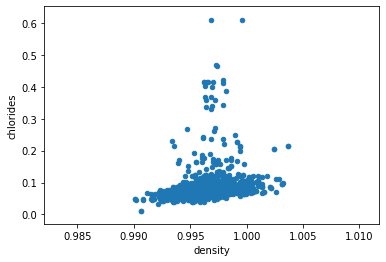

In [64]:
wine_data.plot(kind = 'scatter', x='density',y= 'chlorides' ) 

In [191]:
#Correlation Coefficients

wine_data.corr() 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [178]:
#Change to DataFrame variables

Density = pd.DataFrame(wine_data['density'])
Chloride = pd.DataFrame(wine_data['chlorides'])

In [179]:
Density

,density
0,0.99780
1,0.99680
2,0.99700
3,0.99800
4,0.99780
...,...
1594,0.99490
1595,0.99512
1596,0.99574
1597,0.99547


In [180]:
#Build Linear Regression Model

lm = linear_model.LinearRegression()

model = lm.fit(Density,Chloride)

In [181]:
model.coef_

array([[5.00325924]])

In [182]:
model.intercept_

array([-4.89951549])

In [183]:
#Evaluate the model 
model.score(Density,Chloride) 

0.0402533304935867

In [184]:
#Predict the new value of density

density_new = [[15]]

chloride_predict = model.predict(density_new)

chloride_predict

array([[70.14937313]])

In [185]:
#Predict more values

X = ([5,10,20])

X = pd.DataFrame(X)

Y = model.predict(X)

Y = pd.DataFrame(Y)

df = pd.concat([X,Y], axis=1, keys = [ 'Density','Chloride_Predicted'] )

df 

,Density,Chloride_Predicted
,0,0
0,5,20.116781
1,10,45.133077
2,20,95.165669


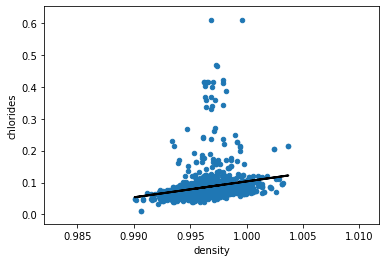

In [189]:
#Visualize the results

wine_data.plot(kind = 'scatter', x='density',y= 'chlorides' ) 

#Plot the regression line

plt.plot(Density,model.predict(Density),color = 'black',linewidth = 2)


plt.show() 

In [95]:
#check for missing values
display(wine_data.isna().any())
#drop any missing values
wine_data = wine_data.dropna()

fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
dtype: bool

In [96]:
#Statistical Summary

des = wine_data['density'].describe() 
des2 = wine_data['chlorides'].describe()

print(des)

print(des2)

count    1599.000000
mean        0.996747
std         0.001887
min         0.990070
25%         0.995600
50%         0.996750
75%         0.997835
max         1.003690
Name: density, dtype: float64
count    1599.000000
mean        0.087467
std         0.047065
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64


AxesSubplot(0.125,0.125;0.775x0.755)


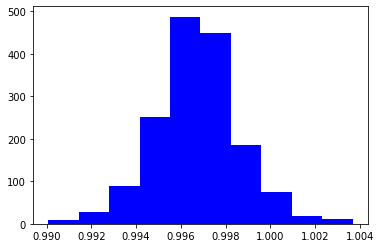

In [97]:
hist = wine_data['density'].hist(grid = False,color = 'blue') 

print(hist) 



AxesSubplot(0.125,0.125;0.775x0.755)


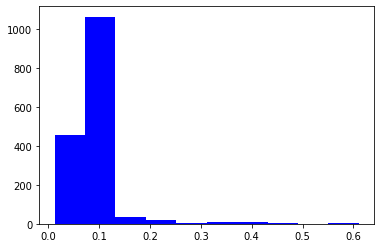

In [98]:
hist2 = wine_data['chlorides'].hist(grid = False,color = 'blue')

print(hist2)  

In [99]:
#Calculate the kurtosis
density_kurtosis = kurtosis(wine_data['density'],fisher = True)

chlorides_kurtosis = kurtosis(wine_data['chlorides'],fisher = True) 

#Calculate the skew

density_skew = skew(wine_data['density'])

chlorides_skew = skew(wine_data['chlorides'])

#Display the kurtosis and skew

display("Density Kurtosis {:.2}".format(density_kurtosis)) 

display("Chlorides Kurtosis {:.2}".format(chlorides_kurtosis)) 


display("Density Skew {:.2}".format(density_skew)) 

display("Chlorides Skew {:.2}".format(chlorides_skew)) 

'Density Kurtosis 0.93'

'Chlorides Kurtosis 4.2e+01'

'Density Skew 0.071'

'Chlorides Skew 5.7'

In [100]:
#kurtosis test

display('Density') 

display(stats.kurtosistest(wine_data['density']))


display('Chlorides') 

display(stats.kurtosistest(wine_data['chlorides'])) 

#skew test

display('Density') 

display(stats.skewtest(wine_data['density']))


display('Chlorides') 

display(stats.skewtest(wine_data['chlorides'])) 




'Density'

KurtosistestResult(statistic=5.417267299481698, pvalue=6.051683433177672e-08)

'Chlorides'

KurtosistestResult(statistic=22.915848586673082, pvalue=3.229402627803515e-116)

'Density'

SkewtestResult(statistic=1.1666040231907682, pvalue=0.24337031787314678)

'Chlorides'

SkewtestResult(statistic=35.46787005326534, pvalue=1.5384656480381497e-275)